<a href="https://colab.research.google.com/github/santhosh2237/Energy-Consumption-Prediction./blob/main/Predict_energy_consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

the Project to predict the energy consumption


In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [100]:

df=pd.read_csv("Energy_consumption.csv")
df.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [101]:
df.describe()

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
std,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


In [102]:
df.isna().sum()

,0
Timestamp,0
Temperature,0
Humidity,0
SquareFootage,0
Occupancy,0
HVACUsage,0
LightingUsage,0
RenewableEnergy,0
DayOfWeek,0
Holiday,0


In [103]:
df['Hour'] = pd.to_datetime(df['Timestamp']).dt.hour
df.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption,Hour
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373,0
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855,1
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888,2
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850,3
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732,4


In [104]:
if "Timestamp" in df.columns:
  df.drop(columns=["Timestamp"],inplace=True)
df.head()

,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption,Hour
0,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373,0
1,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855,1
2,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888,2
3,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850,3
4,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732,4


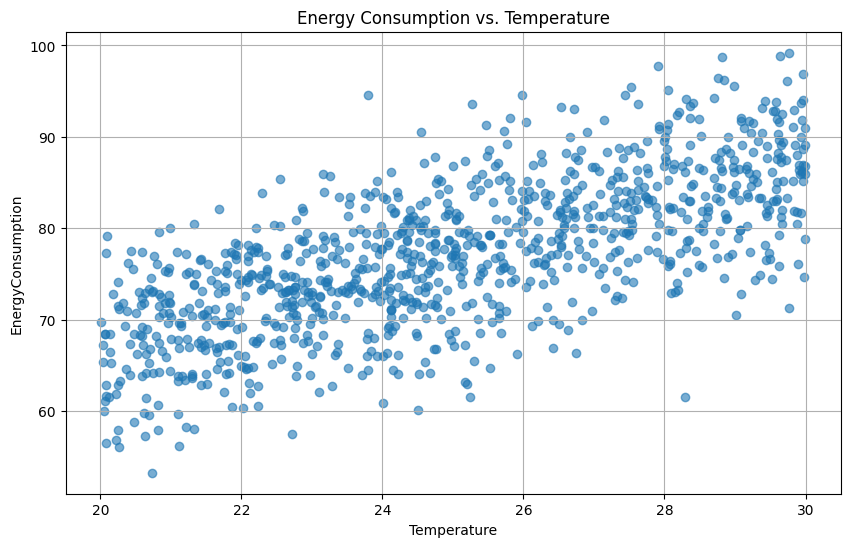

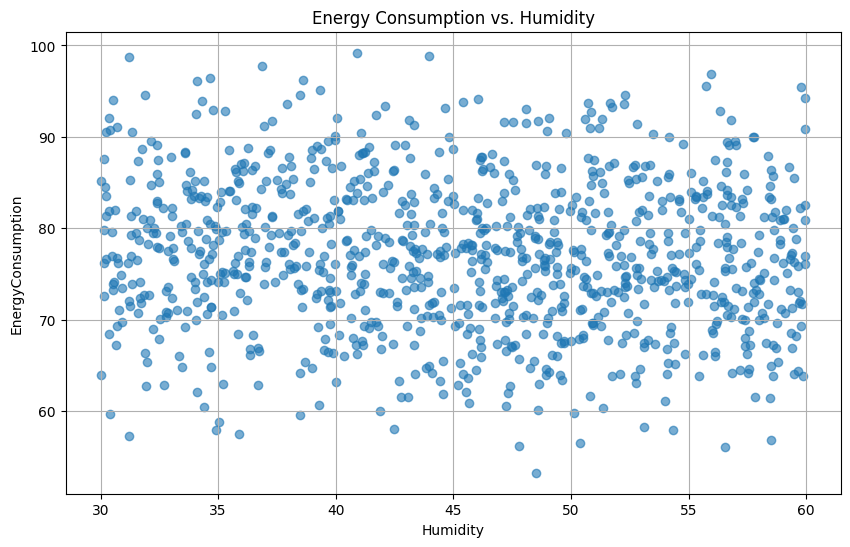

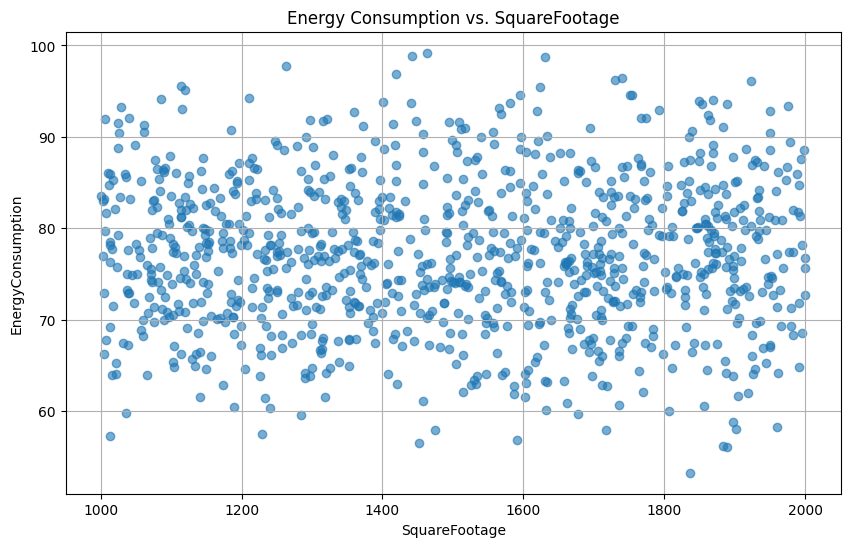

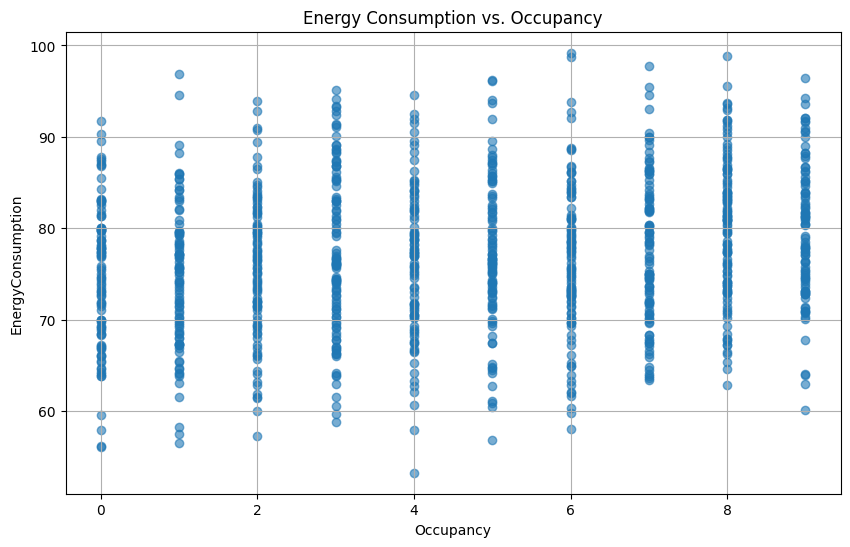

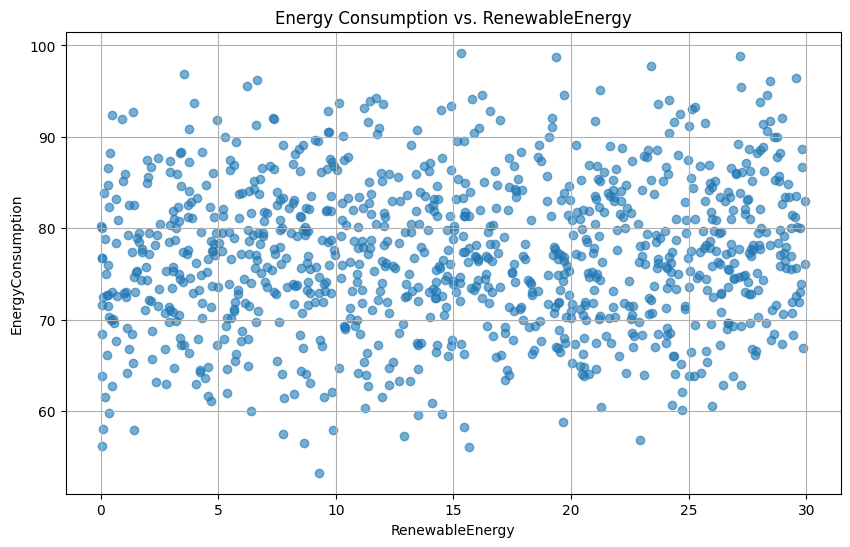

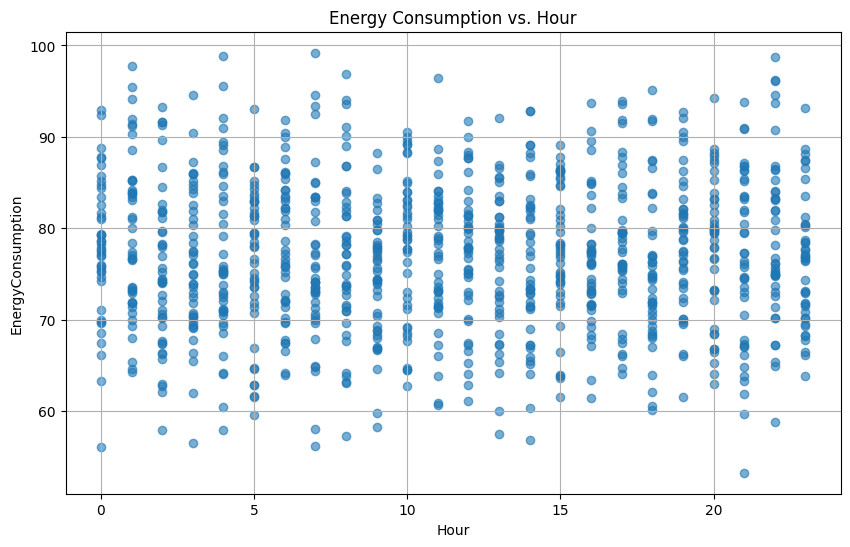

In [105]:
import matplotlib.pyplot as plt
numerical_features = df.select_dtypes(include=['number']).columns.tolist()
# Exclude the target variable itself from the features list if it's there
if 'EnergyConsumption' in numerical_features:
    numerical_features.remove('EnergyConsumption')

# Create a scatter plot for each numerical feature against 'EnergyConsumption'
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    plt.title(f"Energy Consumption vs. {feature}")
    plt.xlabel(feature)
    plt.ylabel("EnergyConsumption")
    plt.scatter(df[feature], df["EnergyConsumption"], alpha=0.6)
    plt.grid(True)
    plt.show()

In [106]:
#encoder
df=pd.get_dummies(df)
df.head()

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption,Hour,HVACUsage_Off,HVACUsage_On,LightingUsage_Off,LightingUsage_On,DayOfWeek_Friday,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,Holiday_No,Holiday_Yes
0,25.139433,43.431581,1565.693999,5,2.774699,75.364373,0,False,True,True,False,False,True,False,False,False,False,False,True,False
1,27.731651,54.225919,1411.064918,1,21.831384,83.401855,1,False,True,False,True,False,False,True,False,False,False,False,True,False
2,28.704277,58.907658,1755.715009,2,6.764672,78.270888,2,True,False,True,False,False,False,False,True,False,False,False,True,False
3,20.080469,50.371637,1452.316318,1,8.623447,56.519850,3,True,False,False,True,False,False,False,False,False,False,True,True,False
4,23.097359,51.401421,1094.130359,9,3.071969,70.811732,4,False,True,True,False,True,False,False,False,False,False,False,True,False


In [107]:
X=df.drop(columns=["EnergyConsumption"])
y=df["EnergyConsumption"]

In [108]:

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
my_pipeline=make_pipeline(
    StandardScaler(),
    LinearRegression()
)

In [109]:
import math
my_pipeline.fit(X_train,y_train)
prediction=my_pipeline.predict(X_test)
rmse=math.sqrt(mean_squared_error(y_test,prediction))
print(rmse)
r2=r2_score(y_test,prediction)
print(r2)

5.158048200043003
0.5938089803091062


In [110]:
#Checking Overfitting
X_train_prediction=my_pipeline.predict(X_train)
X_test_prediction=my_pipeline.predict(X_test)
r2_train=r2_score(y_train,X_train_prediction)
r2_test=r2_score(y_test,X_test_prediction)
print(r2_train)
print(r2_test)


0.6255928147747613
0.5938089803091062


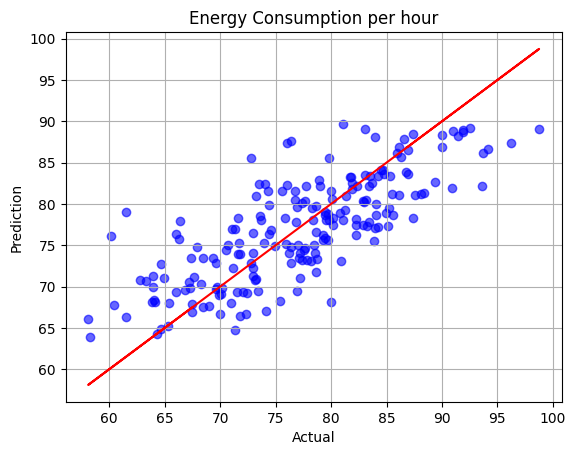

In [111]:
plt.title("Energy Consumption per hour")
plt.ylabel("Prediction")
plt.xlabel("Actual")
plt.scatter(y_test,prediction,color="blue",alpha=0.6)
plt.plot(y_test,y_test,color="red")
plt.grid(True)
plt.show()